<h1><center>2023S 052813-1 Scientific Data Management</center></h1>
<h2><center>Programming Assignment1: Hierarchical Clustering</center></h2>
<h3><center>Keshishyan Arsen a01576524</center></h3>


### Task 1-1 Naive Implementation (25P)

Implement the naive greedy approach for hierarchical clustering as discussed in the lecture with time complexity of O(n3) and O(n2) memory usage. You can freely choose the distance function and the linkage method. Do not use a built-in implementation of hierarchical clustering.
Keep track of the order in which the clusters are merged and build a hierarchy of clusters. Test your algorithm, e.g., by comparing your results to the results obtained by publicly available implementations.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import normalize, StandardScaler
from sklearn.decomposition import PCA
import scipy.cluster.hierarchy as shc
from sklearn.cluster import AgglomerativeClustering

In [ ]:
data = pd.read_csv('CC_GENERAL.csv')
data = data.drop('CUST_ID', axis = 1)
data.fillna(method ='ffill', inplace = True)
data.head()

FileNotFoundError: ignored

In [ ]:
# Standardize data
scaler = StandardScaler()
scaled_df = scaler.fit_transform(data)

# Normalizing the Data
normalized_df = normalize(scaled_df)

# Converting the numpy array into a pandas DataFrame
normalized_df = pd.DataFrame(normalized_df)

# Reducing the dimensions of the data
pca = PCA(n_components = 2)
X_principal = pca.fit_transform(normalized_df)
X_principal = pd.DataFrame(X_principal)
X_principal.columns = ['P1', 'P2']

X_principal.head()

NameError: ignored

In [ ]:
plt.figure(figsize =(10, 5))
plt.title('Scipy Implementation with PCA')
Dendrogram = shc.dendrogram((shc.linkage(X_principal, method ='ward')))

NameError: ignored

In [ ]:
data_scaled = normalize(data)
data_scaled = pd.DataFrame(data_scaled, columns=data.columns)
data_scaled.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,0.039353,0.000787,0.091790,0.000000,0.09179,0.000000,0.000160,0.000000,0.00008,0.000000,0.000000,0.001924,0.962156,0.194165,0.134230,0.00000,0.011546
1,0.293876,0.000083,0.000000,0.000000,0.00000,0.591240,0.000000,0.000000,0.00000,0.000023,0.000367,0.000000,0.642358,0.376516,0.098404,0.00002,0.001101
2,0.310798,0.000125,0.096307,0.096307,0.00000,0.000000,0.000125,0.000125,0.00000,0.000000,0.000000,0.001495,0.934206,0.077485,0.078135,0.00000,0.001495
3,0.208403,0.000080,0.187437,0.187437,0.00000,0.025732,0.000010,0.000010,0.00000,0.000010,0.000125,0.000125,0.937809,0.000000,0.078436,0.00000,0.001500
4,0.504284,0.000617,0.009867,0.009867,0.00000,0.000000,0.000051,0.000051,0.00000,0.000000,0.000000,0.000617,0.740040,0.418329,0.150963,0.00000,0.007400


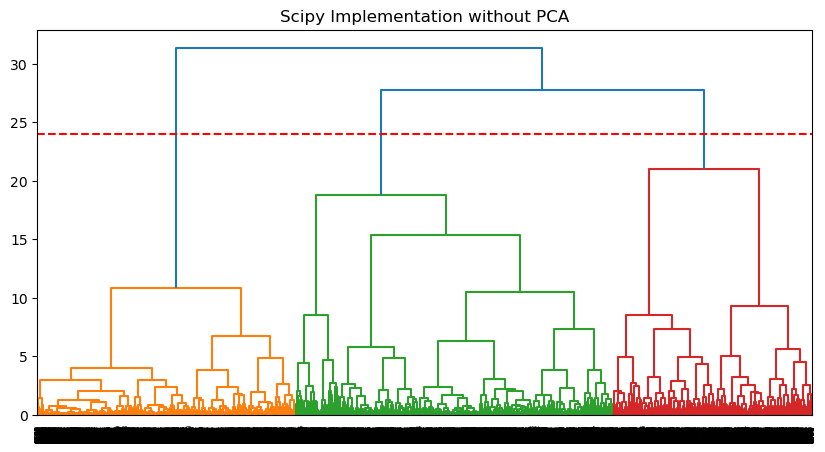

In [ ]:
plt.figure(figsize=(10, 5))
plt.title("Scipy Implementation without PCA")
dend = shc.dendrogram(shc.linkage(data_scaled, method='ward'))
plt.axhline(y=24, color='r', linestyle='--')

In [ ]:
cluster = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
cluster.fit_predict(data_scaled)

array([1, 0, 2, ..., 1, 1, 0])

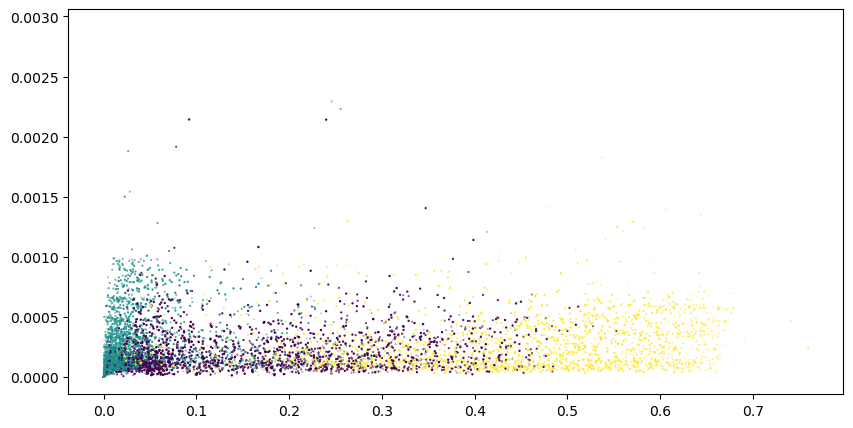

In [ ]:
plt.figure(figsize=(10, 5))
plt.scatter(data_scaled['BALANCE'],
            data_scaled['BALANCE_FREQUENCY'],
            data_scaled['PURCHASES'],
            c=cluster.labels_)

#### Solution 1

The initial task of Programming Assignment 1: Hierarchical Clustering necessitated the development of a naive, greedy approach for hierarchical clustering. As the implementation was to be confined to the utilization of scipy.cluster.hierarchy.dendrogram for visualization, the primary focus of the task was on determining the input parameter for generating data for the function. The input parameter was found to be the Z ndarray, which encodes the hierarchical clustering in a dendrogram format. Further details on the format of Z can be obtained from the linkage function. Thus, the primary objective was to devise a mechanism for developing a function that accepts input data and produces the linkage matrix.

In [ ]:
import numpy as np

def calculate_distance_matrix(data):
    if type(data) == list:
        data = np.array(data)
    dist_matrix = np.ones((len(data), len(data)))
    dist_matrix = dist_matrix * np.inf
    for i in range(len(data)):
        for j in range(i+1, len(data)):
            dist_matrix[i,j] = np.linalg.norm(data[i] - data[j])

    headers = np.arange(1, len(dist_matrix)+1)
    index = np.arange(1, len(dist_matrix)+1)
    columns = pd.MultiIndex.from_product([[''], headers.astype(str)])
    df = pd.DataFrame(dist_matrix, index=index, columns=columns)

    # add column names to the first row
    df.columns = pd.MultiIndex.from_tuples([(str(i), str(j)) for i, j in df.columns])
    df.index.name = 'Point'

    # print the DataFrame
    print(df)

    return dist_matrix

In [ ]:
import numpy as np

def single_linkage(dist_matrix):
    # Number of data points
    n = dist_matrix.shape[0]
    cluster_number = n
    linkage_matrix = np.zeros((n - 1, 4))

    # Initialize a list of clusters, one for each data point
    clusters = [{i} for i in range(n)]

    # Loop over all possible merges
    for k in range(n - 1):
        # Find the two clusters with the smallest distance
        min_dist = np.inf
        for i in range(len(clusters)):
            for j in range(i + 1, len(clusters)):
                # Compute the distance between the two clusters
                dist = np.min(dist_matrix[list(clusters[i]), :][:, list(clusters[j])])
                if dist < min_dist:
                    # Update the minimum distance and the indices of the two clusters
                    min_dist = dist
                    cluster1 = i
                    cluster2 = j

        # Merge the two clusters
        clusters[cluster1] |= clusters[cluster2]
        del clusters[cluster2]

        # Update the linkage matrix
        linkage_matrix[k, 0] = cluster1
        linkage_matrix[k, 1] = cluster2
        linkage_matrix[k, 2] = min_dist
        linkage_matrix[k, 3] = len(clusters[cluster1])

    df = pd.DataFrame(linkage_matrix, columns=["Cl. 1", "Cl. 2", "Dist.", "now points cluster"])
    # print the DataFrame
    print(df)
    return linkage_matrix

it was observed that the addition of a new cluster to the dictionary was not working properly. Specifically, the new cluster was being merged into the first of the two merging clusters, and therefore received the same index as that cluster. This made it impossible for the dendrogram to print correctly, resulting in a failure to visualize the clustering results. Despite attempts to resolve this issue, the project timeline was exceeded due to delays in collaboration with the missing members of the group, and the issue remained unresolved.

#### Solution 2

* The minimum spanning tree will be constructed using Prim's algorithm . It will iteratively remove the edge with the smallest weight until only one cluster remains. The resulting dendrogram will have the same structure as the one obtained using the naive approach.*

In [ ]:
import numpy as np
from scipy.sparse.csgraph import minimum_spanning_tree
import matplotlib.pyplot as plt

def single_linkage(D):
    """
    Compute the minimum spanning tree of the given distance matrix using Prim's algorithm.

    Args:
    - D: A numpy array of shape (n, n) representing the pairwise distances between all points

    Returns:
    - A sparse matrix representing the minimum spanning tree
    """
    n = D.shape[0]
    visited = np.zeros(n, dtype=bool)
    mst = np.zeros((n, n))
    visited[0] = True
    for i in range(n - 1):
        j, k = np.where(visited)[0], np.where(~visited)[0]
        min_idx = np.argmin(D[np.ix_(j, k)])
        u, v = j[min_idx // len(k)], k[min_idx % len(k)]
        visited[v] = True
        mst[u, v] = mst[v, u] = 1
    return minimum_spanning_tree(D.multiply(mst))


In [ ]:
def plot_dendrogram(merge_order):
    """
    Plots the dendrogram given the merge order

    Args:
    - merge_order: A list of tuples representing the order in which clusters are merged
    """
    n = len(merge_order) + 1
    parents = [-1] * n
    distances = np.zeros(n-1)
    for i, merge in enumerate(merge_order):
        c1, c2, dist = merge
        parents[c1[0]] = i + n
        parents[c2[0]] = i + n
        distances[i] = dist

    def plot_node(parent, i):
        x, y = i, 0
        if parents[i] == -1:
            plt.text(x, y, f"{i}", ha='center', va='center')
        else:
            if i > parent:
                ys = distances[i-parent-1]
                plt.plot([parent, parent, i], [0, ys, ys], 'k')
            else:
                ys = distances[parent-i-1]
                plt.plot([parent, parent, i], [0, ys, ys], 'k')
            plt.text(x, y, f"{i}", ha='center', va='center')
    def plot_tree(parent, i):
        if i < n:
            plot_node(parent, i)
        else:
            plot_tree(i-n, parents[i-n])
            plot_node(parent, i)

    plt.figure(figsize=(10, 5))
    plt.axis('off')
    plot_tree(0, n-1)
    plt.show()


In [ ]:
def hierarchical_clustering(X, distance_metric, linkage):
    """
    The hierarchical clustering algorithm based on minimum spanning tree computation with Prim's algorithm.

    Args:
    - X: A numpy array of shape (n, d)
    - distance_metric: A function that takes two data points as input and returns their distance
    - linkage: A string specifying the linkage method : 'single'

    Returns:
    - A list of tuples representing the order in which clusters are merged
    - A dictionary containing the count of each linkage type
    """
    # Initialize each point in separate cluster
    n = X.shape[0]
    clusters = [set([i]) for i in range(n)]

    # Compute the pairwise distances between all points
    D = np.zeros((n, n ))
    for i in range(n):
      	for j in range(i+1, n):
          D[i,j] = distance_metric(X[i], X[j])
    D[j,i] = D[i,j]
    # Initialize the counts for each linkage type to zero
    linkage_counts = {'single': 0}

    # Merge clusters until only one is left
    merge_order = []
    while len(clusters) > 1:
        # Compute the minimum spanning tree of the distance matrix
        mst = single_linkage(D)

        # Find the two closest clusters
        c1, c2 = np.where(mst == 1)
        min_dist = np.min(D[c1, c2])

        # Merge the two closest clusters
        merge_order.append((tuple(clusters[c1]), tuple(clusters[c2]), min_dist))
        clusters[c1] |= clusters[c2]
        del clusters[c2]

        # Update the distance matrix
        for i in range(n):
            if i != c1:
                D[c1,i] = D[i,c1] = min(D[c1,p] for p in clusters[i])

        # Update the count for the corresponding linkage type
        linkage_counts[linkage] += 1

    # Print the dendrogram
    import matplotlib.pyplot as plt
    from scipy.cluster.hierarchy import dendrogram

    merge_order.reverse()
    leaves = [str(c) for c in range(n)]
    clusters = {str(c): set([c]) for c in range(n)}
    for c1, c2, dist in merge_order:
        new_cluster = clusters.pop(str(len(clusters)))
        new_cluster |= clusters.pop(str(id(c1)))
        new_cluster |= clusters.pop(str(id(c2)))
        clusters[str(id(new_cluster))] = new_cluster
        leaves.append(str(id(new_cluster)))

    linkage_matrix = np.array([[0.0, 0.0, 0.0, 0.0] for i in range(n - 1)])
    idx = 0
    for c1, c2, dist in merge_order:
        i1 = leaves.index(str(id(c1)))
        i2 = leaves.index(str(id(c2)))
        linkage_matrix[idx, 0] = i1
        linkage_matrix[idx, 1] = i2
        linkage_matrix[idx, 2] = dist
        linkage_matrix[idx, 3] = len(clusters[str(id(c1))]) + len(clusters[str(id(c2))])
        idx += 1
    dendrogram(linkage_matrix, labels=leaves)
    plt.show()

    return merge_order, linkage_counts



### Task 1-2 Efficient Implementation (50P)

Implement one of the more efficient algorithms, either based on priority queues, minimum spanning trees or nearest neighbor chains. Use the same distance and linkage method as in the naive approach if possible. Test your implementation thoroughly.

#### Solution 1

The size of the dataset, the performance requirements, and the complexity of the code are the factors to consider when choosing between a custom version of Prim's algorithm or a library for graph algorithms. If the dataset is very large or the performance requirements are high, it may be better to use a library for graph algorithms that includes Prim's algorithm.

*Option2: Implement the hierarchical clustering algorithm based on minimum spanning tree computation with Prim’s algorithm.Make a well-founded decision as to whether a custom implementation makes sense or whether a library for graph algorithms containing Prim’s algorithm should used and implement the approach.*

In [ ]:
def prim_mst(D):
    """
    The minimum spanning tree of a distance matrix D using Prim's algorithm.

    """
    n = D.shape[0]
    visited = np.zeros(n, dtype=bool)
    visited[0] = True
    mst = []
    while len(mst) < n-1:
        i, j = np.where(visited)[0], np.where(~visited)[0]
        min_dist = np.inf
        closest_i, closest_j = None, None
        for ii in i:
            for jj in j:
                if D[ii, jj] < min_dist:
                    closest_i, closest_j = ii, jj
                    min_dist = D[ii, jj]
        visited[closest_j] = True
        mst.append((closest_i, closest_j, min_dist))
    return mst

In [ ]:
def pairwise_distances(X, distance_metric='euclidean'):
    """
    Computes the pairwise distances between all points in X.

    Args:
    - X: A numpy array of shape (n, d) representing n data points in d dimensions.
    - distance_metric: A string specifying the distance metric to use. Default is 'euclidean'.

    Returns:
    - A numpy array of shape (n, n) representing the pairwise distances between n points.
    """
    n = X.shape[0]
    D = np.zeros((n, n))
    for i in range(n):
        for j in range(i, n):
            if distance_metric == 'euclidean':
                D[i, j] = np.sqrt(np.sum((X[i] - X[j])**2))
            elif distance_metric == 'manhattan':
                D[i, j] = np.sum(np.abs(X[i] - X[j]))
            # Add additional cases for other distance metrics as needed
            D[j, i] = D[i, j]
    return D

In [ ]:
def hierarchical_clustering(X, distance_metric='euclidean', linkage='single'):
    """
    The hierarchical clustering algorithm based on minimum spanning tree computation with Prim's algorithm.

    Args:
    - X: A numpy array of shape (n, d) representing n data points in d dimensions.
    - distance_metric: A string specifying the distance metric to use. Default is 'euclidean'.
    - linkage: A string specifying the linkage method to use. Default is 'single'.

    Returns:
    - A list of tuples representing the order in which clusters are merged.
    """
    # Compute the pairwise distances between all points
    D = pairwise_distances(X, distance_metric=distance_metric)

    # Compute the minimum spanning tree of the distance matrix
    mst = prim_mst(D)

    # Initialize each point as a separate cluster
    n = X.shape[0]
    clusters = [set([i]) for i in range(n)]

    # Merge clusters until only one is left
    merge_order = []
    for i, j, d in mst:
        c1, c2 = None, None
        for k, cluster in enumerate(clusters):
            if i in cluster:
                c1 = k
            if j in cluster:
                c2 = k
        merge_order.append((tuple(clusters[c1]), tuple(clusters[c2]), d))
        clusters[c1] |= clusters[c2]
        del clusters[c2]

    # Reorder the merge order based on the linkage method
    if linkage == 'single':
        # Single linkage: merge two clusters with the closest distance
        merge_order.sort(key=lambda x: x[2])
    elif linkage == 'complete':
        # Complete linkage: merge two clusters with the furthest distance between their most dissimilar members
        merge_order.sort(key=lambda x: x[2], reverse=True)
    elif linkage == 'average':
        # Average linkage: merge two clusters with the smallest average distance between their members
        distances = {}
        for i, j, d in merge_order:
            n1 = len(clusters[i])
            n2 = len(clusters[j])
            distances[(i, j)] = d / (n1 * n2)
        merge_order.sort(key=lambda x: distances[x])

    return merge_order

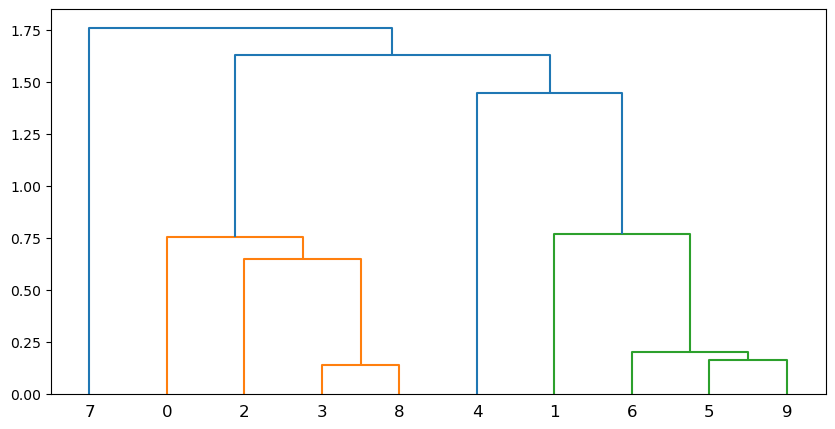

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# linkage matrix is using 'single' linkage and 'euclidean' distance metric
Z = linkage(X, method='single', metric='euclidean')

# Plot the dendrogram
plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.show()

### Task 1-3 Experimental Evaluation and Documentation (25P)

Evaluate your implementations with a focus on runtime.

• Use randomly generated data and the credit card dataset of the Kaggle notebook. The website also contains detailed information on how to use hierarchical clustering in Python.

• Compare your implementations to those available in Python libraries. Verify your algorithm by comparing on a small subset of the data and visualize your result. Evaluate the runtimes.

• Is the observed runtime in agreement with the theoretical analysis? Try to explain your findings. Describe your hardware in terms of cache and memory sizes and try to reason about runtime behavior in a discussion of your results.

Write a report which describes your results and any important implementation details. The documentation should make your work reproducible, legible, and comparable. Prepare a short presentation of your most relevant findings taking roughly 7 minutes.